In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

# Load fitter
ROOT.gSystem.Load("./libTMinFit.so")
ROOT.gInterpreter.Declare('#include "TMinFit.h"')

import ROOT

def load_hist(filename,data_name,sig_name,bkg_name,rebin=1):
    f = ROOT.TFile.Open(filename)
    if not f or f.IsZombie():
        raise RuntimeError(f"Cannot open {filename}")
    hdata = f.Get(data_name)
    hsig  = f.Get(sig_name)
    hbkg  = f.Get(bkg_name)
    if not hdata:
        raise RuntimeError(f"Histogram {data_name} not found")
    if not hsig:
        raise RuntimeError(f"Histogram {sig_name} not found")
    if not hbkg:
        raise RuntimeError(f"Histogram {bkg_name} not found")

    # Detach from file
    hdata = hdata.Clone()
    hsig  = hsig.Clone()
    hbkg  = hbkg.Clone()
    hdata.SetDirectory(0)
    hsig.SetDirectory(0)
    hbkg.SetDirectory(0)
    f.Close()

    if rebin > 1:
        hsig.Rebin(rebin)
        hbkg.Rebin(rebin)
    return hdata, hsig, hbkg

def make_coarse_axes(bestfit, errors,nsigma=5.0,npoints=11):
    axes = []
    for p, err in zip(bestfit, errors):
        axis = np.linspace(
            p - nsigma * err,
            p + nsigma * err,
            npoints
        )
        axes.append(axis)
    return axes

def make_fine_axes(intervals):
    # Build sigma-coordinate axis once
    x = np.concatenate([
        np.linspace(-5.0, -3.0, 4),
        np.linspace(-3.0, -1.0, 6),
        np.linspace(-1.0,  1.0, 21),
        np.linspace( 1.0,  3.0, 6),
        np.linspace( 3.0,  5.0, 4)
    ])

    # Remove possible duplicates at boundaries
    x = np.unique(np.round(x, 10))
    axes = []
    for lo, hi in intervals:
        center = 0.5 * (lo+hi)
        halfwidth = 0.5 * (hi-lo)
        axis = center + halfwidth * x/5.0
        axes.append(axis)
    return axes

def evaluate_grid(fitter, axes, verbose=True):
    n1 = len(axes[0])
    n2 = len(axes[1])
    n3 = len(axes[2])
    n4 = len(axes[3])
    chi2grid = np.empty((n1, n2, n3, n4),dtype=np.float64)
    total = n1 * n2 * n3 * n4
    count = 0
    for i, p1 in enumerate(axes[0]):
        if verbose:
            print(f"slice {i+1}/{n1}")

        for j, p2 in enumerate(axes[1]):
            for k, p3 in enumerate(axes[2]):
                for l, p4 in enumerate(axes[3]):
                    chi2grid[i,j,k,l] = fitter.Evaluate(
                        float(p1),
                        float(p2),
                        float(p3),
                        float(p4)
                    )
                    count += 1
    return chi2grid

def profile_grid(chi2grid):
    chi2min = np.min(chi2grid)
    best_index = np.unravel_index(
        np.argmin(chi2grid),
        chi2grid.shape
    )
    profiles = [
        chi2grid.min(axis=(1,2,3)),
        chi2grid.min(axis=(0,2,3)),
        chi2grid.min(axis=(0,1,3)),
        chi2grid.min(axis=(0,1,2))
    ]
    profiles = [
        p - chi2min
        for p in profiles
    ]
    return chi2min, profiles, best_index

def plot_profiles(axes,profiles,names=None,sigma_line=True):
    if names is None:
        names = ["a1", "b1", "a2", "b2"]
    fig, axs = plt.subplots(2, 2,figsize=(10,8)
    )
    for i, ax in enumerate(axs.flat):
        ax.plot(axes[i],profiles[i],marker="o")
        ax.set_xlabel(names[i])
        ax.set_ylabel(r"$\Delta\chi^2$")
        if sigma_line:
            ax.axhline(1.0,linestyle="--")
        ax.grid(True)
    plt.tight_layout()
    return fig, axs

def find_crossings(x, y, target=30.0):
    crossings = []
    for i in range(len(x)-1):
        y1 = y[i]   - target
        y2 = y[i+1] - target
        if y1 == 0:
            crossings.append(x[i])
        elif y1 * y2 < 0:
            frac = abs(y1) / abs(y2 - y1)
            xc = x[i] + frac * (x[i+1] - x[i])
            crossings.append(xc)
    return crossings

def deltachi2_interval(axes,profiles,target=30.0):
    intervals = []
    for ipar in range(4):
        crossings = find_crossings(
            axes[ipar],
            profiles[ipar],
            target
        )
        if len(crossings) != 2:
            print(
                f"ERROR: parameter {ipar} has "
                f"{len(crossings)} crossings "
                f"at DeltaChi2={target}"
            )
            intervals.append(None)
        else:
            intervals.append(
                (crossings[0], crossings[1])
            )
    return intervals

Welcome to JupyROOT 6.22/06


In [2]:
#f = ROOT.TFile.Open("../input/inputForFitter.root")

#hdata = f.Get("rc_err_data_sgel4_fv200")
#hmc = f.Get("rc_err_mc_sgel4_fv200")
#hsig = f.Get("rc_err_sig_sgel4_fv200")
#hbkg = f.Get("rc_err_bkg_sgel4_fv200")

#hsig.Rebin(10)
#hbkg.Rebin(10)

hdata, hsig, hbkg = load_hist(
    "../input/inputForFitter.root",
    "rc_err_data_sgel4_fv200",
    "rc_err_sig_sgel4_fv200",
    "rc_err_bkg_sgel4_fv200",
    rebin=10
)

myFitter = ROOT.TMinFit( hdata, hsig, hbkg )
ROOT.SetOwnership(myFitter, False)

Constructing TMinFit ...


In [3]:
result = myFitter.RunFit(1)

 **********
 **    1 **SET ERR           1
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 a1           0.00000e+00  1.00000e-04   -1.00000e+00  1.00000e+00
     2 b1           0.00000e+00  1.00000e-04   -1.00000e+01  1.00000e+01
     3 a2           0.00000e+00  1.00000e-04   -1.00000e+00  1.00000e+00
     4 b2           0.00000e+00  1.00000e-04   -1.00000e+01  1.00000e+01
 **********
 **    2 **MIGRAD       2e+05       0.001
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-06
 FCN=57.3767 FROM MIGRAD    STATUS=INITIATE       67 CALLS          68 TOTAL
                     EDM= unknown      STRATEGY= 1      NO ERROR MATRIX       
  EXT PARAMETER               CURRENT GUESS       STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  a1          -2.05119e-03   1.00000e-04   0.00000e+00   2.251

slice 1/11
slice 2/11
slice 3/11
slice 4/11
slice 5/11
slice 6/11
slice 7/11
slice 8/11
slice 9/11
slice 10/11
slice 11/11
Initial center values =  [-0.06536237  0.0356745  -0.00138095 -0.5199229 ]
Initial 1 sigma error =  [0.00055102 0.03127127 0.00162924 0.00353442]


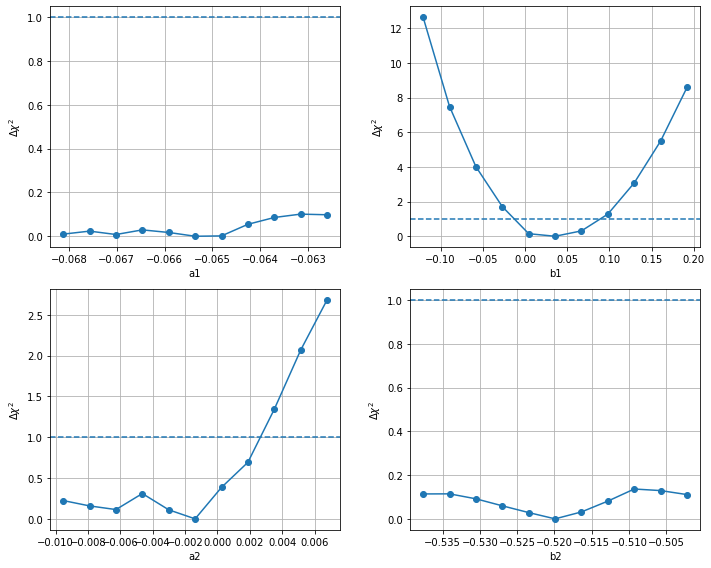

In [4]:
#==================================================
# Retrieve best-fit values/errors and do first grid-scan
#==================================================
bestfit = np.asarray(myFitter.GetPars())
errors  = np.asarray(myFitter.GetErrs())

axes = make_coarse_axes(bestfit,errors,nsigma=5,npoints=11)

chi2grid = evaluate_grid(myFitter,axes)

chi2min, profiles, best_index = profile_grid(chi2grid)

plot_profiles(axes,profiles)

print("Initial center values = ", bestfit)
print("Initial 1 sigma error = ", errors)

slice 1/11
slice 2/11
slice 3/11
slice 4/11
slice 5/11
slice 6/11
slice 7/11
slice 8/11
slice 9/11
slice 10/11
slice 11/11


(<Figure size 720x576 with 4 Axes>,
 array([[<AxesSubplot:xlabel='a1', ylabel='$\\Delta\\chi^2$'>,
         <AxesSubplot:xlabel='b1', ylabel='$\\Delta\\chi^2$'>],
        [<AxesSubplot:xlabel='a2', ylabel='$\\Delta\\chi^2$'>,
         <AxesSubplot:xlabel='b2', ylabel='$\\Delta\\chi^2$'>]],
       dtype=object))

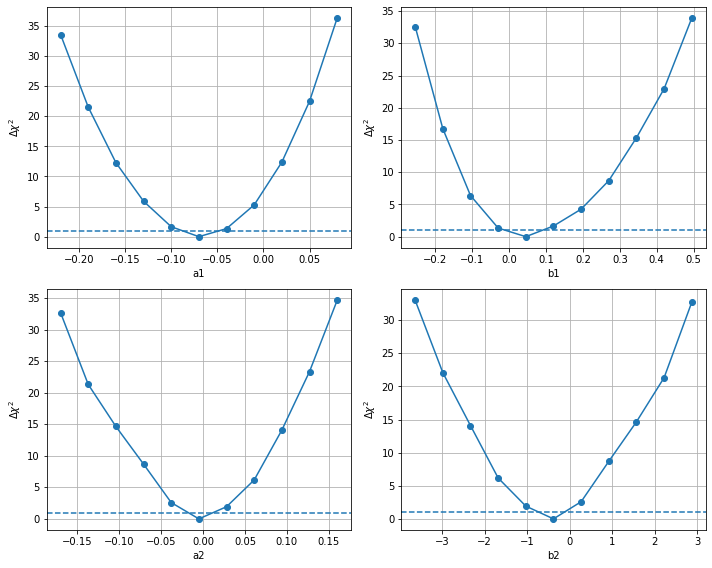

In [5]:
#==================================================
# Refine the scan interactively
#==================================================
center = [-0.070,  0.12,  -0.005, -0.38 ]
errors = [0.030, 0.075, 0.033, 0.65]

axes = make_coarse_axes(center,errors,nsigma=5,npoints=11)

chi2grid = evaluate_grid(myFitter,axes)

chi2min, profiles, best_index = profile_grid(chi2grid)

plot_profiles(axes,profiles)

slice 1/37
slice 2/37
slice 3/37
slice 4/37
slice 5/37
slice 6/37
slice 7/37
slice 8/37
slice 9/37
slice 10/37
slice 11/37
slice 12/37
slice 13/37
slice 14/37
slice 15/37
slice 16/37
slice 17/37
slice 18/37
slice 19/37
slice 20/37
slice 21/37
slice 22/37
slice 23/37
slice 24/37
slice 25/37
slice 26/37
slice 27/37
slice 28/37
slice 29/37
slice 30/37
slice 31/37
slice 32/37
slice 33/37
slice 34/37
slice 35/37
slice 36/37
slice 37/37


(<Figure size 720x576 with 4 Axes>,
 array([[<AxesSubplot:xlabel='a1', ylabel='$\\Delta\\chi^2$'>,
         <AxesSubplot:xlabel='b1', ylabel='$\\Delta\\chi^2$'>],
        [<AxesSubplot:xlabel='a2', ylabel='$\\Delta\\chi^2$'>,
         <AxesSubplot:xlabel='b2', ylabel='$\\Delta\\chi^2$'>]],
       dtype=object))

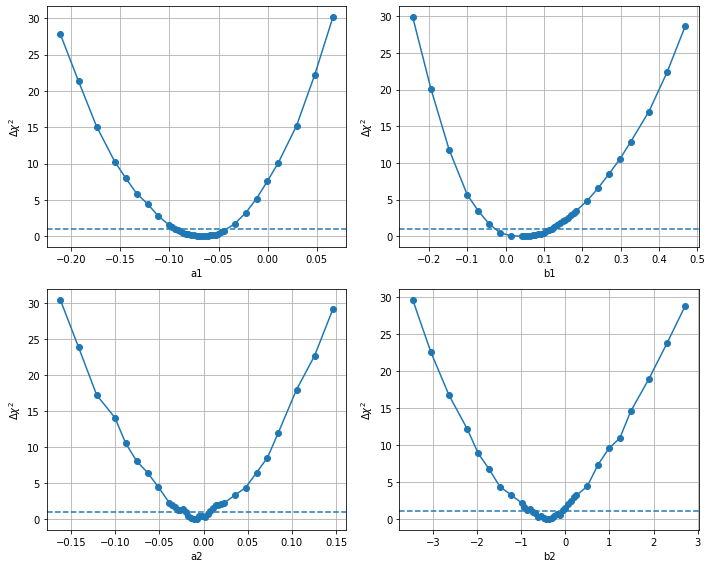

In [6]:
#==================================================
# Find intervals for dChi2=30 & do a fine scan
#==================================================

intervals = deltachi2_interval(axes, profiles, target=30.0)

if any(interval is None for interval in intervals):
    raise RuntimeError(
        "Some parameters do not have exactly two Δχ² crossings."
    )
    
fine_axes = make_fine_axes(intervals)

chi2grid = evaluate_grid(myFitter,fine_axes)

chi2min, profiles, best_index = profile_grid(chi2grid)

plot_profiles(fine_axes,profiles)